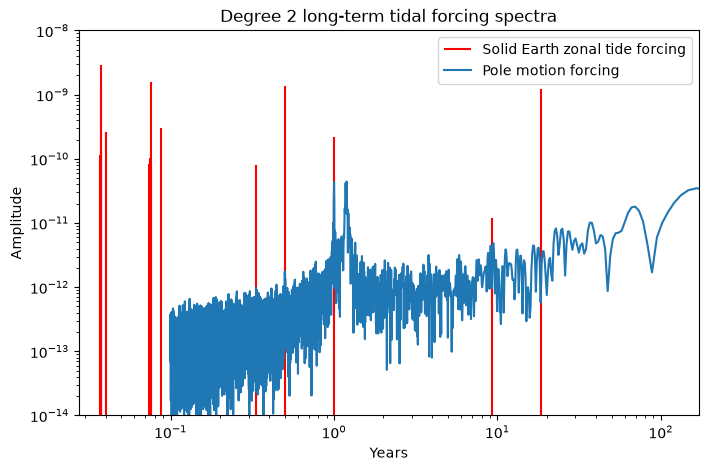

In [45]:
from alna.tide_correction_model import (
    prepare_pole_motion_signal,
    tide_angular_frequencies_to_cycle_per_yr,
    PHI_CONSTANT,
)
from matplotlib.axes import Axes
from matplotlib.pyplot import (
    plot,
    xscale,
    yscale,
    show,
    figure,
    xlim,
    legend,
    ylim,
    title,
    xlabel,
    ylabel,
)
from numpy import array, inf

pole_motion = prepare_pole_motion_signal()
tide_periods = 1 / tide_angular_frequencies_to_cycle_per_yr()
H_f = array(
    [
        0.02793,  # 055.565
        -0.00027,  # 055.575
        -0.00492,  # 056.554
        -0.03100,  # 057.555
        inf,  # 057.565 — not listed in Table 6.7
        -0.00181,  # 058.554
        -0.00673,  # 063.655
        0.00231,  # 065.445
        -0.03518,  # 065.455
        0.00229,  # 065.465
        0.00188,  # 065.655
        -0.00583,  # 073.555
        -0.00288,  # 075.355
        -0.06663,  # 075.555
        -0.02762,  # 075.565
        -0.00258,  # 075.575
        -0.00242,  # 083.655
        -0.01276,  # 085.455
        -0.00529,  # 085.465
        -0.00204,  # 093.555
        -0.00169,  # 095.355
    ]
)
fig = figure(figsize=(8, 5))
ax: Axes = fig.add_subplot()
xlim(10 / 365.25, 170)
ylim(1e-14, 1e-8)
ax.vlines(
    tide_periods,
    ymin=ax.get_ylim()[0],
    ymax=4.4228e-8 * abs(H_f),
    colors="red",
    zorder=0,
    label="Solid Earth zonal tide forcing",
)
xscale("log")
yscale("log")
plot(
    1 / pole_motion.frequencies[pole_motion.frequencies > 0],
    PHI_CONSTANT
    * abs(pole_motion.m_complex[pole_motion.frequencies > 0])
    / len(pole_motion.m_complex),
    zorder=1,
    label="Pole motion forcing",
)
legend(loc="upper right")
title(r"Degree $2$ long-term tidal forcing spectra")
xlabel("Years")
ylabel("Amplitude")
fig.savefig("tidal_forcing_spectra.pdf")
show()